# AI and Data Skills Demand in the Maharashtra Job Market
### A Data-Driven Analysis of Job Postings and Emerging Skill Requirements

**Research Questions:**
1. Which AI skills are most demanded in Maharashtra job postings?
2. How frequently are Python, SQL and Power BI mentioned?
3. How frequently do non-AI jobs require AI-related skills?
4. What is the distribution of job postings by location, experience and work mode?
5. Is there a relationship between required skills, experience and salary?
6. What overall trends can be observed?

**Dataset:** Real job postings scraped from Naukri.com (23,201 rows, 32 columns)

In [2]:
# Environment setup — import the libraries we'll use throughout this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings so we can see full column names and more rows when needed
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

# Check versions (good practice for reproducibility — professors like this)
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 3.0.3
numpy version: 2.4.6


## Phase 2: Loading the Dataset

In [7]:
# Define the path to the raw data (keep raw data separate and untouched)
raw_data_path = "indian_tech_jobs_2026.csv"

# Load the CSV into a pandas DataFrame
df_raw = pd.read_csv(raw_data_path)

# Immediately create a working copy — we will NEVER edit df_raw directly
df = df_raw.copy()

print("Dataset loaded successfully.")
print("Shape of dataset (rows, columns):", df.shape)

Dataset loaded successfully.
Shape of dataset (rows, columns): (23201, 32)


In [9]:
df.tail(3)

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,salary_raw,salary_min_lpa,salary_max_lpa,salary_disclosed,skills_required,skills_count,job_description,posted_date_raw,work_mode,company_size_bucket,job_url,data_source,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
23198,23199,Walk in Interview Python Developer II Hyderabad,Tata Consultancy Services,3.3,"Hyderabad, Pune, Mumbai (All Areas)",Hyderabad,Python Developer,13-Jun,13,8,Not Disclosed,0.0,0.0,False,"Python, Pyspark, SQL, Development, Interviewing",5,Role - Python DeveloperExp. - 6+ yearsWalk in ...,13-Jun,On-site,Large (1000+),https://www.naukri.com/job-listings-walk-in-in...,naukri.com,10-06-2025,Undisclosed,Lead/Architect (9+ Yrs),False,Hyderabad,Data Engineering,0.0,21,False,False
23199,23200,Python Developer,Mediamint,2.8,Hybrid - Hyderabad,Hyderabad,Python Developer,3-5 Yrs,3,5,Not Disclosed,0.0,0.0,False,"AI/ML, API, Python Development, Python, Python...",8,We are looking for a skilled Python Developer ...,Today,Hybrid,Small/Startup (<100),https://www.naukri.com/job-listings-python-dev...,naukri.com,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Data Science,0.0,0,False,False
23200,23201,Python Developer,CMM Level 5 IT Company,3.6,Hyderabad,Hyderabad,Python Developer,7-12 Yrs,7,12,10-16 Lacs PA,10.0,16.0,True,"API, Python Development, Python, Python Framew...",6,Job Title: Senior Python Developer Experience:...,1 day ago,On-site,Small/Startup (<100),https://www.naukri.com/job-listings-python-dev...,naukri.com,10-06-2025,Senior (10-20 LPA),Senior (6-8 Yrs),False,Hyderabad,Data Science,13.0,1,False,False


## Phase 3: Inspecting Rows, Columns and Data Types

In [10]:
# List all column names so we have a complete map of the dataset
print("Total columns:", len(df.columns))
for i, col in enumerate(df.columns, start=1):
    print(i, "-", col)

Total columns: 32
1 - job_id
2 - job_title
3 - company_name
4 - company_rating
5 - location
6 - scraped_city
7 - role_category
8 - experience_raw
9 - experience_min_yrs
10 - experience_max_yrs
11 - salary_raw
12 - salary_min_lpa
13 - salary_max_lpa
14 - salary_disclosed
15 - skills_required
16 - skills_count
17 - job_description
18 - posted_date_raw
19 - work_mode
20 - company_size_bucket
21 - job_url
22 - data_source
23 - scraped_at
24 - salary_tier
25 - experience_tier
26 - is_senior
27 - primary_city
28 - skill_domain
29 - salary_midpoint_lpa
30 - days_since_posted
31 - is_fresher_friendly
32 - salary_negotiable


In [11]:
# info() shows data type and non-null count for every column at once
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               23201 non-null  int64  
 1   job_title            23201 non-null  str    
 2   company_name         23201 non-null  str    
 3   company_rating       23201 non-null  float64
 4   location             23201 non-null  str    
 5   scraped_city         23201 non-null  str    
 6   role_category        23201 non-null  str    
 7   experience_raw       23201 non-null  str    
 8   experience_min_yrs   23201 non-null  int64  
 9   experience_max_yrs   23201 non-null  int64  
 10  salary_raw           23201 non-null  str    
 11  salary_min_lpa       23201 non-null  float64
 12  salary_max_lpa       23201 non-null  float64
 13  salary_disclosed     23201 non-null  bool   
 14  skills_required      23201 non-null  str    
 15  skills_count         23201 non-null  int64  
 1

In [12]:
# Look at a random sample (not just the top rows) to get a more honest first impression
df.sample(5, random_state=42)

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,salary_raw,salary_min_lpa,salary_max_lpa,salary_disclosed,skills_required,skills_count,job_description,posted_date_raw,work_mode,company_size_bucket,job_url,data_source,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
259,260,Data Scientist,Gallagher,3.6,Bengaluru,Bangalore,Data Scientist,3-8 Yrs,3,8,Not Disclosed,0.0,0.0,False,"Data analysis, Data modeling, Analytical, Cons...",8,Introduction We believe that every candidate b...,3+ weeks ago,On-site,Small/Startup (<100),https://www.naukri.com/job-listings-data-scien...,naukri.com,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21,False,False
21183,21184,Deputy Manager,Srmb Srijan,3.5,Kolkata,Kolkata,Business Analyst,8-10 Yrs,8,10,Not Disclosed,0.0,0.0,False,"com, project management, media relations, docu...",8,Disclaimer : This job description has been sou...,3+ weeks ago,On-site,Small/Startup (<100),https://www.naukri.com/job-listings-deputy-man...,naukri.com,10-06-2025,Undisclosed,Senior (6-8 Yrs),True,Kolkata,Business Intelligence,0.0,21,False,False
20313,20314,Sap Po Consultant,Tata Consultancy Services,3.3,Noida,Noida,Business Analyst,5-8 Yrs,5,8,Not Disclosed,0.0,0.0,False,"SAP PI, Sap Popi, SAP SD, Sap Pi Po, Pi / Po, ...",8,Required Information . Required Technical Skil...,2 days ago,On-site,Large (1000+),https://www.naukri.com/job-listings-sap-po-con...,naukri.com,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Noida,Business Intelligence,0.0,2,False,False
8541,8542,IoT Data Analysis Professional,Segula Technologies India,3.4,Chennai,Chennai,Data Analyst,5-10 Yrs,5,10,Not Disclosed,0.0,0.0,False,"Data analysis, Simulation, System integration,...",8,Bachelor degree . DATA ANALYST Full-time . At ...,1 day ago,On-site,Small/Startup (<100),https://www.naukri.com/job-listings-iot-data-a...,naukri.com,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Chennai,AI/ML/DL,0.0,1,False,False
2004,2005,Azure Data Engineer - ADF & PySpark (PAN India),Tata Consultancy Services,3.3,"Pune, Hyderabad, Bengaluru",Pune,Data Scientist,6-10 Yrs,6,10,Not Disclosed,0.0,0.0,False,"Azure, PySpark, Azure Databricks, Azure Data F...",8,Key ResponsibilitiesDesign and develop ETL/ELT...,1 week ago,On-site,Large (1000+),https://www.naukri.com/job-listings-azure-data...,naukri.com,10-06-2025,Undisclosed,Senior (6-8 Yrs),False,Pune,Cloud & DevOps,0.0,7,False,False


In [13]:
df.dtypes

job_id                   int64
job_title                  str
company_name               str
company_rating         float64
location                   str
scraped_city               str
role_category              str
experience_raw             str
experience_min_yrs       int64
experience_max_yrs       int64
salary_raw                 str
salary_min_lpa         float64
salary_max_lpa         float64
salary_disclosed          bool
skills_required            str
skills_count             int64
job_description            str
posted_date_raw            str
work_mode                  str
company_size_bucket        str
job_url                    str
data_source                str
scraped_at                 str
salary_tier                str
experience_tier            str
is_senior                 bool
primary_city               str
skill_domain               str
salary_midpoint_lpa    float64
days_since_posted        int64
is_fresher_friendly       bool
salary_negotiable         bool
dtype: o

## Phase 4: Checking Missing Values

In [14]:
# Count missing values per column
missing_count = df.isnull().sum()

# Convert to percentage of total rows — easier to judge severity
missing_percent = (missing_count / len(df) * 100).round(2)

# Combine into one summary table, sorted so the worst columns appear first
missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
}).sort_values(by='missing_count', ascending=False)

# Only show columns that actually have missing values
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_percent
job_url,53,0.23


In [15]:
# Look at a few rows where job_url is missing, to understand what's going on
df[df['job_url'].isnull()].head(5)

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,salary_raw,salary_min_lpa,salary_max_lpa,salary_disclosed,skills_required,skills_count,job_description,posted_date_raw,work_mode,company_size_bucket,job_url,data_source,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4,9,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Large (1000+),NaN,naukri.com,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0,0,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Small/Startup (<100),NaN,naukri.com,10-06-2025,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5,10,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Small/Startup (<100),NaN,naukri.com,10-06-2025,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21,False,False
5,6,Data Scientist,Top Rated IT Enterprise,3.6,"Chennai, Bengaluru",Bangalore,Data Scientist,3-8 Yrs,3,8,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Small/Startup (<100),NaN,naukri.com,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Chennai,Data Science,0.0,21,False,False
6,7,Data Scientist,Leading IT Firm,3.6,"Chennai, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5,10,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Small/Startup (<100),NaN,naukri.com,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Chennai,Data Science,0.0,21,False,False


In [16]:
# Check for common "fake null" placeholder text across key text columns
placeholder_values = ['not available', 'n/a', 'na', 'not disclosed', 'none', '-', 'nil', '']

key_text_columns = ['skills_required', 'job_description', 'salary_raw', 'experience_raw', 'location']

for col in key_text_columns:
    # Convert to lowercase and strip spaces so we catch variations like "Not Available " or "NOT AVAILABLE"
    matches = df[col].astype(str).str.strip().str.lower().isin(placeholder_values)
    print(f"{col}: {matches.sum()} rows ({round(matches.sum()/len(df)*100, 2)}%) contain placeholder text")

skills_required: 547 rows (2.36%) contain placeholder text
job_description: 404 rows (1.74%) contain placeholder text
salary_raw: 20433 rows (88.07%) contain placeholder text
experience_raw: 7 rows (0.03%) contain placeholder text
location: 0 rows (0.0%) contain placeholder text


In [17]:
# See a few actual rows where skills_required is a placeholder, not real data
df[df['skills_required'].astype(str).str.strip().str.lower() == 'not available'].head(5)

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,salary_raw,salary_min_lpa,salary_max_lpa,salary_disclosed,skills_required,skills_count,job_description,posted_date_raw,work_mode,company_size_bucket,job_url,data_source,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4,9,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Large (1000+),NaN,naukri.com,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0,0,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Small/Startup (<100),NaN,naukri.com,10-06-2025,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5,10,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Small/Startup (<100),NaN,naukri.com,10-06-2025,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21,False,False
5,6,Data Scientist,Top Rated IT Enterprise,3.6,"Chennai, Bengaluru",Bangalore,Data Scientist,3-8 Yrs,3,8,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Small/Startup (<100),NaN,naukri.com,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Chennai,Data Science,0.0,21,False,False
6,7,Data Scientist,Leading IT Firm,3.6,"Chennai, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5,10,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Small/Startup (<100),NaN,naukri.com,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Chennai,Data Science,0.0,21,False,False


In [18]:
# Check overlap: rows where BOTH skills_required AND job_description are placeholders
skills_missing = df['skills_required'].astype(str).str.strip().str.lower() == 'not available'
desc_missing = df['job_description'].astype(str).str.strip().str.lower() == 'not available'

both_missing = skills_missing & desc_missing

print("Rows with skills_required missing:", skills_missing.sum())
print("Rows with job_description missing:", desc_missing.sum())
print("Rows where BOTH are missing (truly unusable for skill extraction):", both_missing.sum())
print("Percentage of total dataset:", round(both_missing.sum() / len(df) * 100, 2), "%")

Rows with skills_required missing: 547
Rows with job_description missing: 404
Rows where BOTH are missing (truly unusable for skill extraction): 395
Percentage of total dataset: 1.7 %


## Phase 5: Checking Duplicates

In [19]:
# Check for completely identical rows (every single column matches)
exact_duplicates = df.duplicated().sum()
print("Exact duplicate rows (all columns identical):", exact_duplicates)

Exact duplicate rows (all columns identical): 0


In [20]:
# Check for duplicates based on the columns that identify a "unique posting"
# Two rows with the same title + company + location are very likely the same job, even if job_id/scraped_at differ
key_columns = ['job_title', 'company_name', 'location']

subset_duplicates = df.duplicated(subset=key_columns).sum()
print("Duplicate postings (same title + company + location):", subset_duplicates)

Duplicate postings (same title + company + location): 0


In [21]:
# Show a few of these duplicate postings so you can see what's happening
df[df.duplicated(subset=key_columns, keep=False)].sort_values(by=key_columns).head(10)

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,salary_raw,salary_min_lpa,salary_max_lpa,salary_disclosed,skills_required,skills_count,job_description,posted_date_raw,work_mode,company_size_bucket,job_url,data_source,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable


## Phase 6: Filtering Maharashtra Postings

In [22]:
# Before filtering, look at every unique value in primary_city
# This helps us catch spelling variants, suffixes like "(Baner)", etc.
unique_cities = df['primary_city'].unique()
print("Total unique city values:", len(unique_cities))
for city in sorted(unique_cities.astype(str)):
    print(city)

Total unique city values: 198
Agra
Ahemdabad
Ahmedabad
Ahmedabad(Ahmedabad Cantonment)
Ahmedabad(Ambli Bopal)
Ahmedabad(Bodakdev)
Ahmedabad(Cg Road)
Ahmedabad(Changodar)
Ahmedabad(Chhatral)
Ahmedabad(Dholera)
Ahmedabad(Gift City)
Ahmedabad(Gota)
Ahmedabad(Krishnanagar)
Ahmedabad(Makarba)
Ahmedabad(Navrangpura)
Ahmedabad(Prahlad Nagar)
Ahmedabad(Ring Road)
Ahmedabad(Sanand)
Ahmedabad(Shela)
Ahmedabad(Sindhu Bhavan Road)
Ahmedabad(South Bopal)
Ahmedabad(Thaltej)
Ahmedabad(Vastrapur)
Bahadurgarh
Bangalore
Bhopal
Bhubaneswar
Chandigarh
Chennai
Chennai(Akkarai)
Chennai(Ambattur Industrial Estate)
Chennai(Ambattur)
Chennai(Aminjikarai)
Chennai(Anna Nagar)
Chennai(Anna Salai)
Chennai(Chennai Central Rs)
Chennai(Gopalapuram)
Chennai(Guindy)
Chennai(Kattankulathur)
Chennai(Kilpauk)
Chennai(Kovilambakkam)
Chennai(Manali +1)
Chennai(Manapakkam)
Chennai(Mettukuppam)
Chennai(Mogappair)
Chennai(Mylapore)
Chennai(Nandanam)
Chennai(Navalur)
Chennai(Nungambakkam +1)
Chennai(Omr)
Chennai(Pallavaram)
Che

### Building the Maharashtra filter

In [23]:
# Based on manual inspection of all 198 unique city values, Maharashtra-related
# postings are identified by these keywords appearing in primary_city.
# "Remote" and "Pan India" are intentionally excluded — we cannot verify
# they are Maharashtra-based, and we don't want to assume/invent that.

maharashtra_keywords = ['Mumbai', 'Pune', 'Nagpur']

# Build a regex pattern that matches any of these words, case-insensitive
pattern = '|'.join(maharashtra_keywords)

# Filter rows where primary_city contains any of these keywords
maharashtra_mask = df['primary_city'].astype(str).str.contains(pattern, case=False, na=False)

df_maharashtra = df[maharashtra_mask].copy()

print("Total rows in full dataset:", len(df))
print("Rows matching Maharashtra filter:", len(df_maharashtra))
print("Percentage of dataset:", round(len(df_maharashtra) / len(df) * 100, 2), "%")

Total rows in full dataset: 23201
Rows matching Maharashtra filter: 6076
Percentage of dataset: 26.19 %


In [24]:
# Double check: list the exact unique city values that were captured by our filter
print(sorted(df_maharashtra['primary_city'].unique()))

['Mumbai', 'Mumbai Suburban', 'Mumbai Suburban(Goregaon)', 'Mumbai(Aarey Milk Colony)', 'Mumbai(Airoli)', 'Mumbai(Andheri East)', 'Mumbai(Andheri West +1)', 'Mumbai(Andheri)', 'Mumbai(Bandra Kurla Complex)', 'Mumbai(Belapur)', 'Mumbai(Bhayander West)', 'Mumbai(Borivali West)', 'Mumbai(Chandivali)', 'Mumbai(Cst +1)', 'Mumbai(Dadar)', 'Mumbai(Ghansoli)', 'Mumbai(Goregaon East +3)', 'Mumbai(Goregaon East)', 'Mumbai(Goregaon)', 'Mumbai(Hiranandani Gardens Powai)', 'Mumbai(Linking Road)', 'Mumbai(Lower Parel)', 'Mumbai(Mahalaxmi)', 'Mumbai(Malad East)', 'Mumbai(Malad West)', 'Mumbai(Malad)', 'Mumbai(Marol)', 'Mumbai(Masjid Bunder)', 'Mumbai(Mulund)', 'Mumbai(Parel)', 'Mumbai(Powai)', 'Mumbai(Prabhadevi)', 'Mumbai(Rabale)', 'Mumbai(Santacruz)', 'Mumbai(Seepz +1)', 'Mumbai(Sion)', 'Mumbai(Tardeo)', 'Mumbai(Turbhe)', 'Mumbai(Vidyavihar)', 'Mumbai(Vikhroli)', 'Mumbai(Wadala East)', 'Mumbai(Wadala)', 'Nagpur', 'Pune', 'Pune(Aundh +5)', 'Pune(Balewadi Phata)', 'Pune(Balewadi)', 'Pune(Baner +1)', 

## Phase 7: Cleaning Location, Job Title, Experience and Work-Mode Fields

### Step 7.1: Cleaning the location field

In [25]:
# First, look at how many unique Maharashtra city values we're dealing with,
# and how many rows fall into each — this tells us how to group them sensibly
df_maharashtra['primary_city'].value_counts()

primary_city
Mumbai                       3276
Pune                         2606
Mumbai Suburban                33
Pune(Baner)                    22
Pune(Hinjewadi Phase 1)        11
                             ... 
Nagpur                          1
Mumbai(Mahalaxmi)               1
Mumbai(Mulund)                  1
Mumbai(Goregaon East +3)        1
Mumbai(Aarey Milk Colony)       1
Name: count, Length: 72, dtype: int64

### Step 7.1 (continued): Creating a clean city-level column

In [26]:
# Create a new, clean city column by extracting just the base city name
# (Mumbai / Pune / Nagpur), collapsing all area-level suffixes into it.
# We KEEP the original primary_city column untouched alongside this new one.

def clean_city(value):
    value = str(value)
    if 'Mumbai' in value:
        return 'Mumbai'
    elif 'Pune' in value:
        return 'Pune'
    elif 'Nagpur' in value:
        return 'Nagpur'
    else:
        return value  # fallback, shouldn't happen since we already filtered

df_maharashtra['city_clean'] = df_maharashtra['primary_city'].apply(clean_city)

# Verify the result
df_maharashtra['city_clean'].value_counts()

city_clean
Mumbai    3382
Pune      2693
Nagpur       1
Name: count, dtype: int64

In [27]:
  print(df_maharashtra['city_clean'].value_counts().sum(), "should equal", len(df_maharashtra))

6076 should equal 6076


### Step 7.2: Cleaning the job title field

In [29]:
# Check how many unique job titles exist, and glance at a sample
print("Unique job titles in Maharashtra subset:", df_maharashtra['job_title'].nunique())
df_maharashtra['job_title'].sample(15, random_state=1)

Unique job titles in Maharashtra subset: 3679


7526                                 Data Executive - IC&Q
7829                   India & APJ Senior Benefits Analyst
1429                                         Data Engineer
13984                                   Generative AI-4-DN
17775                                     Business Analyst
23159        Interfacing Developer (Senior & Junior Level)
11545                            Machine Learning Engineer
1904                    Senior Engineer - Data Engineering
11527                                       Data Scientist
23132                                 Full Stack Developer
7908                      Senior Process Analyst - Celonis
1410     Data Engineer : SAP Datasphere and amp & ETL D...
12153                                      AI/ML Associate
2189                                 Data Engineering Lead
1841                               Data Scientist SME Lead
Name: job_title, dtype: str

In [30]:
# 1. Check for leading/trailing whitespace issues
whitespace_issues = (df_maharashtra['job_title'] != df_maharashtra['job_title'].str.strip()).sum()
print("Titles with leading/trailing whitespace:", whitespace_issues)

# 2. Check for case-only duplicates (e.g. "Data Analyst" vs "data analyst" counted as different)
raw_unique = df_maharashtra['job_title'].nunique()
lower_unique = df_maharashtra['job_title'].str.lower().str.strip().nunique()
print("Unique titles (raw):", raw_unique)
print("Unique titles (lowercased + trimmed):", lower_unique)
print("Difference (titles that were only different due to case/spacing):", raw_unique - lower_unique)

# 3. Check for broken HTML entities like 'and amp &', '&amp;', '&nbsp;'
html_entity_issues = df_maharashtra['job_title'].str.contains('and amp|&amp;|&nbsp;|&#', case=False, na=False, regex=True).sum()
print("Titles with broken HTML entity artifacts:", html_entity_issues)

# Show a few examples if any exist
if html_entity_issues > 0:
    print(df_maharashtra.loc[df_maharashtra['job_title'].str.contains('and amp|&amp;|&nbsp;|&#', case=False, na=False, regex=True), 'job_title'].head(10))

Titles with leading/trailing whitespace: 0
Unique titles (raw): 3679
Unique titles (lowercased + trimmed): 3617
Difference (titles that were only different due to case/spacing): 62
Titles with broken HTML entity artifacts: 1
1410    Data Engineer : SAP Datasphere and amp & ETL D...
Name: job_title, dtype: str


In [31]:
# Light, safe cleaning: standardize case consistency only.
# We do NOT alter word order, remove words, or bucket categories here.

df_maharashtra['job_title_clean'] = df_maharashtra['job_title'].str.strip().str.title()

# Verify: how many unique titles now?
print("Unique job titles before cleaning:", df_maharashtra['job_title'].nunique())
print("Unique job titles after cleaning:", df_maharashtra['job_title_clean'].nunique())

Unique job titles before cleaning: 3679
Unique job titles after cleaning: 3617


In [32]:
  df_maharashtra[['job_title', 'job_title_clean']].sample(10, random_state=1)

,job_title,job_title_clean
7526,Data Executive - IC&Q,Data Executive - Ic&Q
7829,India & APJ Senior Benefits Analyst,India & Apj Senior Benefits Analyst
1429,Data Engineer,Data Engineer
13984,Generative AI-4-DN,Generative Ai-4-Dn
17775,Business Analyst,Business Analyst
23159,Interfacing Developer (Senior & Junior Level),Interfacing Developer (Senior & Junior Level)
11545,Machine Learning Engineer,Machine Learning Engineer
1904,Senior Engineer - Data Engineering,Senior Engineer - Data Engineering
11527,Data Scientist,Data Scientist
23132,Full Stack Developer,Full Stack Developer


### Step 7.3: Verifying the experience field

In [33]:
# Check basic statistics for experience columns
print(df_maharashtra[['experience_min_yrs', 'experience_max_yrs']].describe())

# Logical check: does min ever exceed max? That would indicate a data error
illogical_experience = (df_maharashtra['experience_min_yrs'] > df_maharashtra['experience_max_yrs']).sum()
print("\nRows where experience_min_yrs > experience_max_yrs:", illogical_experience)

# Check experience_tier values (the pre-built category column)
print("\n", df_maharashtra['experience_tier'].value_counts())

       experience_min_yrs  experience_max_yrs
count         6076.000000         6076.000000
mean             4.159974            7.831139
std              2.889644            3.890703
min              0.000000            0.000000
25%              2.000000            5.000000
50%              4.000000            8.000000
75%              6.000000           10.000000
max             20.000000           30.000000

Rows where experience_min_yrs > experience_max_yrs: 19

 experience_tier
Mid (3-5 Yrs)              2733
Senior (6-8 Yrs)           1263
Junior (0-2 Yrs)           1203
Fresher                     580
Lead/Architect (9+ Yrs)     297
Name: count, dtype: int64


In [34]:
# Inspect the actual rows where min > max, to understand what's going on
illogical_rows = df_maharashtra[df_maharashtra['experience_min_yrs'] > df_maharashtra['experience_max_yrs']]

# Show the relevant columns so we can judge what happened
illogical_rows[['job_title', 'experience_raw', 'experience_min_yrs', 'experience_max_yrs', 'experience_tier']]

,job_title,experience_raw,experience_min_yrs,experience_max_yrs,experience_tier
1109,Walk-in || Hiring For Snowflake Data Engineer,11-Jun,11,8,Lead/Architect (9+ Yrs)
1701,Walk-in || Data Scientist,13-Jun,13,8,Lead/Architect (9+ Yrs)
2000,Walk-in || Data Engineer,13-Jun,13,8,Lead/Architect (9+ Yrs)
2065,Walk-in || Tcs is conducting Walk In Interview...,13-Jun,13,8,Lead/Architect (9+ Yrs)
2226,Walk-in || Gcp Data Engineer,13-Jun,13,8,Lead/Architect (9+ Yrs)
7107,Walk-in || Business Intelligence-Data Analyst,13-Jun,13,8,Lead/Architect (9+ Yrs)
7360,Walk-in || Business Analyst (Banking),17 May - 15 Aug,17,15,Lead/Architect (9+ Yrs)
7808,Walkin Drive | Pune | June 13 | Data Scientist,13-Jun,13,8,Lead/Architect (9+ Yrs)
7809,Walk-in || Data Scientist(6+ yrs exp candidate...,13-Jun,13,8,Lead/Architect (9+ Yrs)
7810,Walk-in || Data Scientist AI& ML,13-Jun,13,8,Lead/Architect (9+ Yrs)


In [35]:
# Flag rows with logically inconsistent experience data (likely date-parsing artifacts)
# We do NOT delete these rows or guess-correct the values — we flag them so they can be
# excluded specifically from experience-based analysis (RQ4, RQ5) while remaining valid
# for other research questions (e.g. skills, location).

df_maharashtra['experience_data_reliable'] = df_maharashtra['experience_min_yrs'] <= df_maharashtra['experience_max_yrs']

print("Reliable experience rows:", df_maharashtra['experience_data_reliable'].sum())
print("Unreliable (flagged) rows:", (~df_maharashtra['experience_data_reliable']).sum())

Reliable experience rows: 6057
Unreliable (flagged) rows: 19


#### I found 19 rows where minimum experience exceeded maximum experience. On inspection, I traced this to a parsing artifact — interview dates in 'Walk-in' job postings were misread as experience values by the original data extraction process. Rather than guessing the correct values or deleting these rows outright, I flagged them with a reliability indicator so they're excluded only from experience-specific analysis, while remaining available for skill and location-based questions.

### Step 7.4: Verifying the work_mode field

In [36]:
# Check all unique values in work_mode within the Maharashtra subset
print(df_maharashtra['work_mode'].value_counts())
print("\nTotal unique values:", df_maharashtra['work_mode'].nunique())

# Check for any missing values specifically in this subset
print("\nMissing values in work_mode:", df_maharashtra['work_mode'].isnull().sum())

work_mode
On-site    5274
Hybrid      758
Remote       44
Name: count, dtype: int64

Total unique values: 3

Missing values in work_mode: 0


## Phase 8: Cleaning Salary Information

In [37]:
# Check salary disclosure rate specifically within the Maharashtra subset
print(df_maharashtra['salary_disclosed'].value_counts())
print("\nPercentage disclosed:", round(df_maharashtra['salary_disclosed'].mean() * 100, 2), "%")

# Look at basic stats for salary, but ONLY where it's actually disclosed
salary_disclosed_subset = df_maharashtra[df_maharashtra['salary_disclosed'] == True]
print("\nRows with disclosed salary:", len(salary_disclosed_subset))
print(salary_disclosed_subset[['salary_min_lpa', 'salary_max_lpa', 'salary_midpoint_lpa']].describe())

salary_disclosed
False    5309
True      767
Name: count, dtype: int64

Percentage disclosed: 12.62 %

Rows with disclosed salary: 767
       salary_min_lpa  salary_max_lpa  salary_midpoint_lpa
count      767.000000      767.000000           767.000000
mean        12.856545       20.681708            16.769113
std          9.675138       12.369738            10.821711
min          0.000000        0.050000             0.050000
25%          6.000000       12.000000            10.000000
50%         10.000000       18.000000            14.000000
75%         15.500000       30.000000            22.500000
max         85.000000       90.000000            87.500000


In [38]:
# Investigate rows where salary is marked as disclosed but salary_min_lpa is 0
zero_salary_rows = df_maharashtra[(df_maharashtra['salary_disclosed'] == True) & (df_maharashtra['salary_min_lpa'] == 0)]

print("Rows with disclosed=True but salary_min_lpa = 0:", len(zero_salary_rows))
zero_salary_rows[['job_title', 'salary_raw', 'salary_min_lpa', 'salary_max_lpa']]

Rows with disclosed=True but salary_min_lpa = 0: 17


,job_title,salary_raw,salary_min_lpa,salary_max_lpa
1056,Senior Data Engineer,0-22 Lacs PA,0.0,22.0
1346,Data Engineer,"50,000-15 Lacs PA",0.0,0.5
1929,Data Analyst,"50,000-2.5 Lacs PA",0.0,0.5
2248,Data Engineer - Support Role,0-12 Lacs PA,0.0,12.0
2338,Data Engineer,0-22 Lacs PA,0.0,22.0
7724,Data Processing Analyst,0-13 Lacs PA,0.0,13.0
8075,Data Analyst 0-2 years Experience,"50,000-1.75 Lacs PA",0.0,0.5
11682,Digital Quality Engineer,"50,000-2.5 Lacs PA",0.0,0.5
11714,AIML Engineer,0-12 Lacs PA,0.0,12.0
12412,Ai Ml Engineer,"50,000-2.5 Lacs PA",0.0,0.5


In [39]:
# Pattern A vs Pattern B can be distinguished cleanly by salary_max_lpa:
# Pattern B (broken mixed-unit rows) all show suspiciously small max values (under 1 LPA),
# while Pattern A (genuine "0-X Lacs" ranges) shows realistic max values (12+ LPA).

df_maharashtra['salary_data_reliable'] = True  # default: assume reliable

# Flag Pattern B: disclosed=True, min=0, AND max suspiciously below 1 LPA
# (a max salary under 1 LPA for a tech job is not realistic — sign of a parsing error)
salary_issue_mask = (
    (df_maharashtra['salary_disclosed'] == True) &
    (df_maharashtra['salary_min_lpa'] == 0) &
    (df_maharashtra['salary_max_lpa'] < 1)
)

df_maharashtra.loc[salary_issue_mask, 'salary_data_reliable'] = False

print("Flagged as unreliable salary data:", salary_issue_mask.sum())
print("\nRows flagged:")
print(df_maharashtra.loc[salary_issue_mask, ['job_title', 'salary_raw', 'salary_min_lpa', 'salary_max_lpa']])

# Confirm total counts
print("\nTotal disclosed rows:", (df_maharashtra['salary_disclosed'] == True).sum())
print("Reliable disclosed salary rows:", ((df_maharashtra['salary_disclosed'] == True) & (df_maharashtra['salary_data_reliable'] == True)).sum())

Flagged as unreliable salary data: 9

Rows flagged:
                               job_title           salary_raw  salary_min_lpa  salary_max_lpa
1346                       Data Engineer    50,000-15 Lacs PA             0.0             0.5
1929                        Data Analyst   50,000-2.5 Lacs PA             0.0             0.5
8075   Data Analyst 0-2 years Experience  50,000-1.75 Lacs PA             0.0             0.5
11682           Digital Quality Engineer   50,000-2.5 Lacs PA             0.0             0.5
12412                     Ai Ml Engineer   50,000-2.5 Lacs PA             0.0             0.5
15850                      Data Engineer    50,000-15 Lacs PA             0.0             0.5
17752                   Business Analyst     60,000-2 Lacs PA             0.0             0.6
18464                   Business Analyst  50,000-1.25 Lacs PA             0.0             0.5
22512          Python Software Developer     50,000-3 Lacs PA             0.0             0.5

Total d

## Phase 9: Extracting AI and Data Skills from Job Postings
### Step 9.1: Understanding the skills_required text structure

In [40]:
# Look at a larger sample of skills_required to understand formatting patterns
# We exclude the 547 placeholder rows we already identified, to see only real data
real_skills = df_maharashtra[df_maharashtra['skills_required'].str.strip().str.lower() != 'not available']

print("Rows with real skills text:", len(real_skills))
print()
for s in real_skills['skills_required'].sample(10, random_state=7):
    print("-", s)

Rows with real skills text: 5953

- Computer science, Backend, Version control, Web development, Debugging, Application development, software quality, SDLC
- Version control, GIT, Postgresql, Django, MySQL, Javascript, MongoDB, Unit testing
- Azure, Fabric, SQL, Pyspark, Python, Python, Data, Microsoft Azure
- Banking Sector, Business Analysis, Product Management, Financial Services, PMI, Mobile Banking, Management, Finance
- Geospatial Data, Time Series, Statistical Modeling, Python, Machine Learning, Statistics, Time, Data
- trading, algorithms, software, scalability, research, sql, microservices, spring
- MLOps, Machine Learning, GCP, Python, SQL, Machine
- Generative Ai, Artificial Intelligence, Machine Learning, Python, Intelligence, Software, Machine, Software development
- Product innovation, Failure analysis, thermal, Agile, Sensors, Forecasting, Operations, Analytics
- Security management, Compliance, Coding, Analytical, Focus, Machine learning, Regulatory compliance, Architec

In [41]:
# Also check job_description for comparison — do AI-related terms appear there
# even when NOT listed in skills_required? This matters for RQ3.
for d in real_skills['job_description'].sample(3, random_state=7):
    print(d[:400])
    print("---")

Short Description We are looking for a skilled Software Engineer II with strong experie...
---
We are looking for a Python / Django developer who is well versed in Python and the Dja...
---
Develop automated testing frameworks to ensure efficient testing of complex data workfl...
---


### Step 9.2: Defining the skill keyword dictionary

In [42]:
# Define the skills we're searching for.
# Each skill maps to one or more text patterns to search for (case-insensitive).
# For multi-word or ambiguous terms (like AI), we use safer, more specific phrases.

skill_keywords = {
    'Python': ['python'],
    'SQL': ['sql'],
    'Power BI': ['power bi', 'powerbi'],
    'Machine Learning': ['machine learning'],
    'Deep Learning': ['deep learning'],
    'Artificial Intelligence': ['artificial intelligence', 'generative ai', 'genai', 'ai/ml', 'ai-ml'],
    'NLP': ['nlp', 'natural language processing'],
    'LLM': ['llm', 'large language model'],
    'MLOps': ['mlops'],
    'TensorFlow/PyTorch': ['tensorflow', 'pytorch'],
    'Computer Vision': ['computer vision'],
    'Excel': ['excel'],
    'Tableau': ['tableau'],
    'Cloud (AWS/Azure/GCP)': ['aws', 'azure', 'gcp', 'google cloud', 'amazon web services'],
    'Statistics': ['statistics', 'statistical'],
}

print("Total skill categories defined:", len(skill_keywords))
for skill, patterns in skill_keywords.items():
    print(f"  {skill}: {patterns}")

Total skill categories defined: 15
  Python: ['python']
  SQL: ['sql']
  Power BI: ['power bi', 'powerbi']
  Machine Learning: ['machine learning']
  Deep Learning: ['deep learning']
  Artificial Intelligence: ['artificial intelligence', 'generative ai', 'genai', 'ai/ml', 'ai-ml']
  NLP: ['nlp', 'natural language processing']
  LLM: ['llm', 'large language model']
  MLOps: ['mlops']
  TensorFlow/PyTorch: ['tensorflow', 'pytorch']
  Computer Vision: ['computer vision']
  Excel: ['excel']
  Tableau: ['tableau']
  Cloud (AWS/Azure/GCP): ['aws', 'azure', 'gcp', 'google cloud', 'amazon web services']
  Statistics: ['statistics', 'statistical']


### Step 9.3: Applying skill detection to each posting

In [43]:
# Combine skills_required and job_description into one searchable text field per row.
# We search BOTH fields because a skill might be mentioned in the description
# even if it's missing from the (sometimes truncated, max-8-item) skills_required tag list.
# We do NOT use job_title, per your rule of not assuming skills from titles.

searchable_text = (
    df_maharashtra['skills_required'].astype(str) + ' ' +
    df_maharashtra['job_description'].astype(str)
).str.lower()

# For each skill, create a True/False column indicating whether ANY of its
# patterns appear anywhere in the combined searchable text for that row.
for skill, patterns in skill_keywords.items():
    df_maharashtra[f'skill_{skill}'] = searchable_text.apply(
        lambda text: any(pattern in text for pattern in patterns)
    )

print("Skill columns created:")
skill_columns = [f'skill_{s}' for s in skill_keywords.keys()]
print(skill_columns)

Skill columns created:
['skill_Python', 'skill_SQL', 'skill_Power BI', 'skill_Machine Learning', 'skill_Deep Learning', 'skill_Artificial Intelligence', 'skill_NLP', 'skill_LLM', 'skill_MLOps', 'skill_TensorFlow/PyTorch', 'skill_Computer Vision', 'skill_Excel', 'skill_Tableau', 'skill_Cloud (AWS/Azure/GCP)', 'skill_Statistics']


In [44]:
# Quick check: how many rows matched at least one skill?
any_skill_matched = df_maharashtra[skill_columns].any(axis=1)
print("Rows matching at least one tracked skill:", any_skill_matched.sum())
print("Rows matching NONE of the tracked skills:", (~any_skill_matched).sum())

# Preview a few rows with their skill flags
df_maharashtra[['job_title', 'skills_required'] + skill_columns].sample(5, random_state=3)

Rows matching at least one tracked skill: 3513
Rows matching NONE of the tracked skills: 2563


,job_title,skills_required,skill_Python,skill_SQL,skill_Power BI,skill_Machine Learning,skill_Deep Learning,skill_Artificial Intelligence,skill_NLP,skill_LLM,skill_MLOps,skill_TensorFlow/PyTorch,skill_Computer Vision,skill_Excel,skill_Tableau,skill_Cloud (AWS/Azure/GCP),skill_Statistics
23182,Senior .NET Developer,"angular, react.js, css, git, query optimizatio...",False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2193,Data Engineer,"Data Engineer, Airflow, Sap, Kafka, Informatic...",False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
18569,"Sr. Business Analyst, CORP Applications, Infor...","Management accounting, Delivery management, SA...",False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12183,Lead Engineer,"Automation, Simulation, Diagnostics, Coding, M...",False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
18571,"Senior Business Analyst - Product Management, ...","Product management, Loans, Manager Quality Ass...",False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [45]:
# Look at what role_category these "no skill matched" rows belong to
no_skill_rows = df_maharashtra[~df_maharashtra[skill_columns].any(axis=1)]
print(no_skill_rows['role_category'].value_counts())

# Also manually eyeball a few of their skills_required and job_description text,
# to make sure we're not missing an obvious skill mention due to a bug
print()
for idx, row in no_skill_rows.sample(5, random_state=5).iterrows():
    print("Job Title:", row['job_title'])
    print("Skills listed:", row['skills_required'])
    print("Description snippet:", row['job_description'][:200])
    print("---")

role_category
Business Analyst             1018
Data Analyst                  545
Data Scientist                360
Python Developer              319
Data Engineer                 171
Machine Learning Engineer     150
Name: count, dtype: int64

Job Title: Business Technology Solutions Manager - Patient Strategy & Services
Skills listed: business technology, management consulting, risk management, business development, change management, salesforce, stakeholder management, compliance
Description snippet: Preferred Qualifications. Salesforce certifications:Health Cloud Consultant, Life Scien...
---
Job Title: Principal Engineer - AI & Data Systems
Skills listed: Architecture, Agile scrum, TDD, Consulting, Cloud, Presales, Stakeholder management, Distribution system
Description snippet: Job Summary We are looking for a highly experienced Principal Engineer with 10+ y...
---
Job Title: Mobile Application Developer ? Android
Skills listed: CSS, XML, JavaScript, XHTML/HTML, Mobile applicatio

In [46]:
df_maharashtra[['job_title', 'skills_required'] + skill_columns].sample(5, random_state=3)

,job_title,skills_required,skill_Python,skill_SQL,skill_Power BI,skill_Machine Learning,skill_Deep Learning,skill_Artificial Intelligence,skill_NLP,skill_LLM,skill_MLOps,skill_TensorFlow/PyTorch,skill_Computer Vision,skill_Excel,skill_Tableau,skill_Cloud (AWS/Azure/GCP),skill_Statistics
23182,Senior .NET Developer,"angular, react.js, css, git, query optimizatio...",False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2193,Data Engineer,"Data Engineer, Airflow, Sap, Kafka, Informatic...",False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
18569,"Sr. Business Analyst, CORP Applications, Infor...","Management accounting, Delivery management, SA...",False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12183,Lead Engineer,"Automation, Simulation, Diagnostics, Coding, M...",False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
18571,"Senior Business Analyst - Product Management, ...","Product management, Loans, Manager Quality Ass...",False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [47]:
# Check the FULL, untruncated text for row 23182 to verify the SQL match
pd.set_option('display.max_colwidth', None)  # temporarily show full text, not truncated

print("Full skills_required:")
print(df_maharashtra.loc[23182, 'skills_required'])
print()
print("Full job_description (first 500 chars):")
print(df_maharashtra.loc[23182, 'job_description'][:500])

pd.set_option('display.max_colwidth', 50)  # reset back to default truncation

Full skills_required:
angular, react.js, css, git, query optimization, t-sql, sql server, Optimization

Full job_description (first 500 chars):
A global, digitally enabled business that empowers a brighter future by connecting mill...


## Phase 10: Creating Research Variables

In [48]:
# Variable 1: total number of tracked skills matched per posting (out of your 15)
df_maharashtra['tracked_skill_count'] = df_maharashtra[skill_columns].sum(axis=1)

# Variable 2: does this posting require ANY AI-specific skill?
# (narrower than "any tracked skill" — only the AI-focused subset)
ai_specific_columns = [
    'skill_Machine Learning', 'skill_Deep Learning', 'skill_Artificial Intelligence',
    'skill_NLP', 'skill_LLM', 'skill_MLOps', 'skill_TensorFlow/PyTorch', 'skill_Computer Vision'
]
df_maharashtra['requires_ai_skill'] = df_maharashtra[ai_specific_columns].any(axis=1)

# Variable 3: is this an "AI-titled/categorized" role, based on role_category?
# This lets us compare AI-labeled roles vs. roles that merely REQUIRE AI skills (RQ3)
ai_role_categories = ['Data Scientist', 'Machine Learning Engineer']
df_maharashtra['is_ai_labeled_role'] = df_maharashtra['role_category'].isin(ai_role_categories)

# Quick check of all three new variables
print(df_maharashtra['tracked_skill_count'].describe())
print()
print("Requires AI skill:", df_maharashtra['requires_ai_skill'].sum(), "/", len(df_maharashtra))
print("Is AI-labeled role:", df_maharashtra['is_ai_labeled_role'].sum(), "/", len(df_maharashtra))

count    6076.000000
mean        1.134463
std         1.297744
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: tracked_skill_count, dtype: float64

Requires AI skill: 1263 / 6076
Is AI-labeled role: 2549 / 6076


In [49]:
# Verify: what is the ACTUAL full breakdown of role_category across all of df_maharashtra?
print(df_maharashtra['role_category'].value_counts())

# And confirm this matches is_ai_labeled_role exactly
data_scientist_count = (df_maharashtra['role_category'] == 'Data Scientist').sum()
ml_engineer_count = (df_maharashtra['role_category'] == 'Machine Learning Engineer').sum()
print("\nData Scientist:", data_scientist_count)
print("Machine Learning Engineer:", ml_engineer_count)
print("Sum:", data_scientist_count + ml_engineer_count)
print("is_ai_labeled_role total:", df_maharashtra['is_ai_labeled_role'].sum())

role_category
Data Scientist               1611
Business Analyst             1295
Data Analyst                  993
Machine Learning Engineer     938
Python Developer              822
Data Engineer                 417
Name: count, dtype: int64

Data Scientist: 1611
Machine Learning Engineer: 938
Sum: 2549
is_ai_labeled_role total: 2549


## Phase 11: Exploratory Data Analysis
### RQ1: Which AI skills are most demanded in Maharashtra job postings?

In [50]:
# Count how many postings mention each skill, and sort from most to least common
skill_frequency = df_maharashtra[skill_columns].sum().sort_values(ascending=False)

# Convert to percentage of total Maharashtra postings for easier interpretation
skill_frequency_pct = (skill_frequency / len(df_maharashtra) * 100).round(2)

# Combine into one clean summary table
skill_summary = pd.DataFrame({
    'postings_count': skill_frequency,
    'percentage_of_postings': skill_frequency_pct
})

skill_summary

,postings_count,percentage_of_postings
skill_SQL,1395,22.96
skill_Python,1321,21.74
skill_Cloud (AWS/Azure/GCP),1025,16.87
skill_Machine Learning,892,14.68
skill_Artificial Intelligence,582,9.58
skill_Excel,327,5.38
skill_Power BI,300,4.94
skill_NLP,246,4.05
skill_LLM,171,2.81
skill_Statistics,166,2.73


### RQ2: How frequently are Python, SQL and Power BI mentioned?

In [51]:
# Pull out just the three named skills from the RQ1 table for a focused view
rq2_skills = skill_summary.loc[['skill_Python', 'skill_SQL', 'skill_Power BI']]
rq2_skills

,postings_count,percentage_of_postings
skill_Python,1321,21.74
skill_SQL,1395,22.96
skill_Power BI,300,4.94


### RQ3: How frequently do non-AI jobs require AI-related skills?

In [52]:
# Define "non-AI jobs" as postings where role_category is NOT Data Scientist or ML Engineer
non_ai_jobs = df_maharashtra[~df_maharashtra['is_ai_labeled_role']]

print("Total non-AI-labeled postings:", len(non_ai_jobs))

# Among these, how many still require at least one AI-specific skill?
non_ai_requiring_ai_skill = non_ai_jobs['requires_ai_skill'].sum()
print("Non-AI-labeled postings that DO require an AI skill:", non_ai_requiring_ai_skill)
print("Percentage:", round(non_ai_requiring_ai_skill / len(non_ai_jobs) * 100, 2), "%")

# Break this down by role_category, for more useful detail
print()
non_ai_jobs.groupby('role_category')['requires_ai_skill'].agg(['sum', 'count'])

Total non-AI-labeled postings: 3527
Non-AI-labeled postings that DO require an AI skill: 184
Percentage: 5.22 %



,sum,count
role_category,,
Business Analyst,24,1295
Data Analyst,76,993
Data Engineer,16,417
Python Developer,68,822


In [53]:
# Confirm the two summary numbers we still need
print("Total non-AI-labeled postings:", len(non_ai_jobs))
print("Non-AI-labeled postings requiring an AI skill:", non_ai_jobs['requires_ai_skill'].sum())
print("Percentage:", round(non_ai_jobs['requires_ai_skill'].sum() / len(non_ai_jobs) * 100, 2), "%")

# Add a percentage column to your role_category breakdown so rates are comparable
breakdown = non_ai_jobs.groupby('role_category')['requires_ai_skill'].agg(['sum', 'count'])
breakdown['percentage'] = (breakdown['sum'] / breakdown['count'] * 100).round(2)
breakdown.sort_values('percentage', ascending=False)

Total non-AI-labeled postings: 3527
Non-AI-labeled postings requiring an AI skill: 184
Percentage: 5.22 %


,sum,count,percentage
role_category,,,
Python Developer,68,822,8.27
Data Analyst,76,993,7.65
Data Engineer,16,417,3.84
Business Analyst,24,1295,1.85


### RQ4: Distribution of postings by location, experience and work mode

In [54]:
# Location distribution
print("=== By City ===")
print(df_maharashtra['city_clean'].value_counts())
print("\n=== By Work Mode ===")
print(df_maharashtra['work_mode'].value_counts())
print("\n=== By Experience Tier ===")
# Use only rows flagged as reliable experience data
reliable_exp = df_maharashtra[df_maharashtra['experience_data_reliable']]
print(reliable_exp['experience_tier'].value_counts())

=== By City ===
city_clean
Mumbai    3382
Pune      2693
Nagpur       1
Name: count, dtype: int64

=== By Work Mode ===
work_mode
On-site    5274
Hybrid      758
Remote       44
Name: count, dtype: int64

=== By Experience Tier ===
experience_tier
Mid (3-5 Yrs)              2733
Senior (6-8 Yrs)           1263
Junior (0-2 Yrs)           1203
Fresher                     580
Lead/Architect (9+ Yrs)     278
Name: count, dtype: int64


### RQ5: Relationship between skills, experience and salary

In [55]:
# Build the RQ5 analysis subset: salary disclosed AND reliable, per Phase 8
salary_subset = df_maharashtra[
    (df_maharashtra['salary_disclosed'] == True) &
    (df_maharashtra['salary_data_reliable'] == True)
]

print("Rows usable for RQ5 (reliable disclosed salary):", len(salary_subset))

# Correlation between tracked_skill_count and salary_midpoint_lpa
correlation = salary_subset['tracked_skill_count'].corr(salary_subset['salary_midpoint_lpa'])
print("Correlation (skill count vs salary):", round(correlation, 3))

# Correlation between experience and salary (only reliable experience rows within this subset)
salary_exp_subset = salary_subset[salary_subset['experience_data_reliable']]
correlation2 = salary_exp_subset['experience_min_yrs'].corr(salary_exp_subset['salary_midpoint_lpa'])
print("Correlation (min experience years vs salary):", round(correlation2, 3))

Rows usable for RQ5 (reliable disclosed salary): 758
Correlation (skill count vs salary): 0.239
Correlation (min experience years vs salary): 0.562


In [56]:
# Average salary_midpoint_lpa for postings WITH vs WITHOUT each skill
# (using only the salary_subset of 758 reliable disclosed rows)

skill_salary_comparison = []
for skill in skill_columns:
    with_skill = salary_subset[salary_subset[skill] == True]['salary_midpoint_lpa'].mean()
    without_skill = salary_subset[salary_subset[skill] == False]['salary_midpoint_lpa'].mean()
    count_with = salary_subset[skill].sum()
    skill_salary_comparison.append({
        'skill': skill.replace('skill_', ''),
        'avg_salary_with_skill': round(with_skill, 2) if count_with > 0 else None,
        'avg_salary_without_skill': round(without_skill, 2),
        'postings_with_skill_in_salary_subset': count_with
    })

skill_salary_df = pd.DataFrame(skill_salary_comparison).sort_values('avg_salary_with_skill', ascending=False)
skill_salary_df

,skill,avg_salary_with_skill,avg_salary_without_skill,postings_with_skill_in_salary_subset
10,Computer Vision,28.75,16.89,5
6,NLP,27.02,16.39,41
4,Deep Learning,26.39,16.72,19
8,MLOps,24.08,16.84,13
3,Machine Learning,24.06,15.91,98
5,Artificial Intelligence,23.89,15.76,112
7,LLM,21.47,16.68,45
14,Statistics,21.28,16.85,20
13,Cloud (AWS/Azure/GCP),20.68,15.99,158
9,TensorFlow/PyTorch,19.69,16.88,24


## Phase 12: Creating Tables and Visualizations
### Chart 1 (RQ1): Skill Frequency in Maharashtra Job Postings

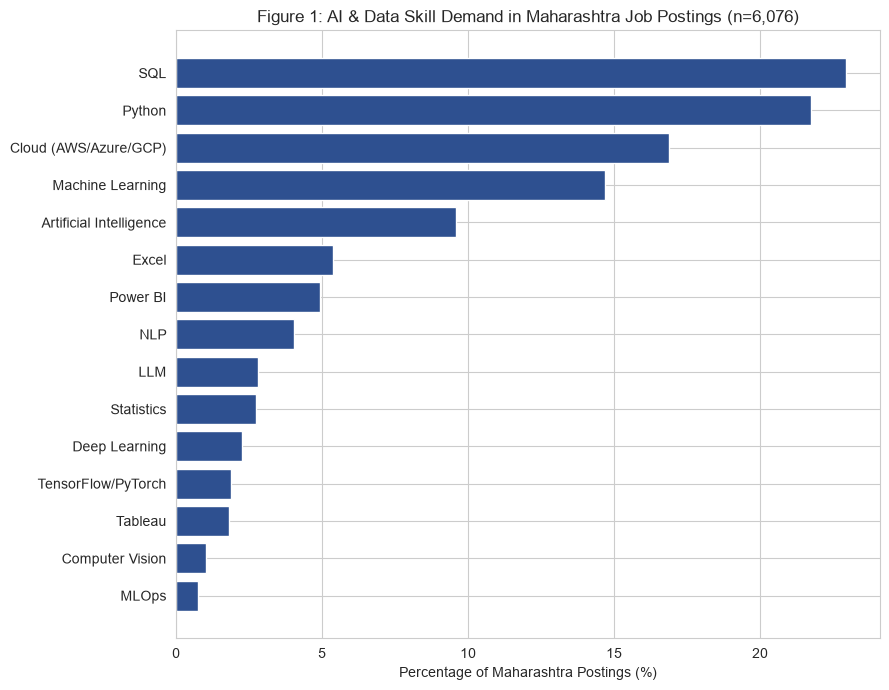

In [59]:
# Set a consistent, clean visual style for all charts in this notebook
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Prepare data: skill names (without the "skill_" prefix) and their percentages
chart_data = skill_summary.copy()
chart_data.index = chart_data.index.str.replace('skill_', '')
chart_data = chart_data.sort_values('percentage_of_postings', ascending=True)  # ascending for horizontal bar order

# Create the horizontal bar chart
plt.figure(figsize=(9, 7))
plt.barh(chart_data.index, chart_data['percentage_of_postings'], color='#2E5090')
plt.xlabel('Percentage of Maharashtra Postings (%)')
plt.title('Figure 1: AI & Data Skill Demand in Maharashtra Job Postings (n=6,076)')
plt.tight_layout()

# Save the chart as an image file for your report
plt.savefig('../Output/fig1_skill_frequency.png', dpi=300, bbox_inches='tight')

plt.show()

### Chart 2 (RQ2): Python, SQL and Power BI Comparison

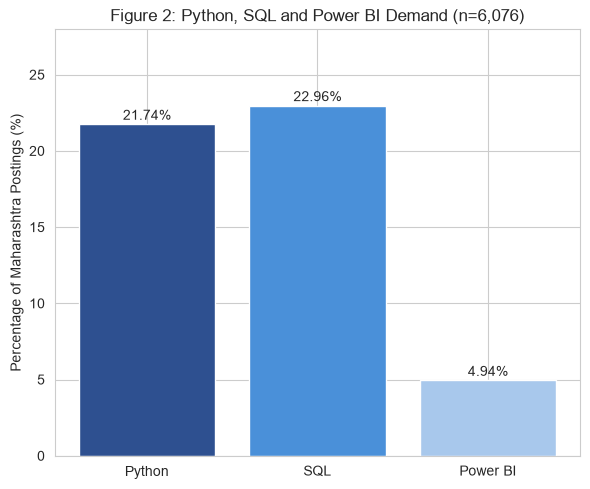

In [60]:
# Prepare data: just the three named skills
rq2_chart_data = rq2_skills.copy()
rq2_chart_data.index = rq2_chart_data.index.str.replace('skill_', '')

plt.figure(figsize=(6, 5))
bars = plt.bar(rq2_chart_data.index, rq2_chart_data['percentage_of_postings'],
                color=['#2E5090', '#4A90D9', '#A8C8EC'])
plt.ylabel('Percentage of Maharashtra Postings (%)')
plt.title('Figure 2: Python, SQL and Power BI Demand (n=6,076)')

# Add the exact percentage on top of each bar for precision
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.3,
              f'{height}%', ha='center', fontsize=10)

plt.ylim(0, max(rq2_chart_data['percentage_of_postings']) + 5)
plt.tight_layout()
plt.savefig('../Output/fig2_python_sql_powerbi.png', dpi=300, bbox_inches='tight')
plt.show()

### Chart 3 (RQ3): AI Skill Requirement Among Non-AI-Labeled Roles

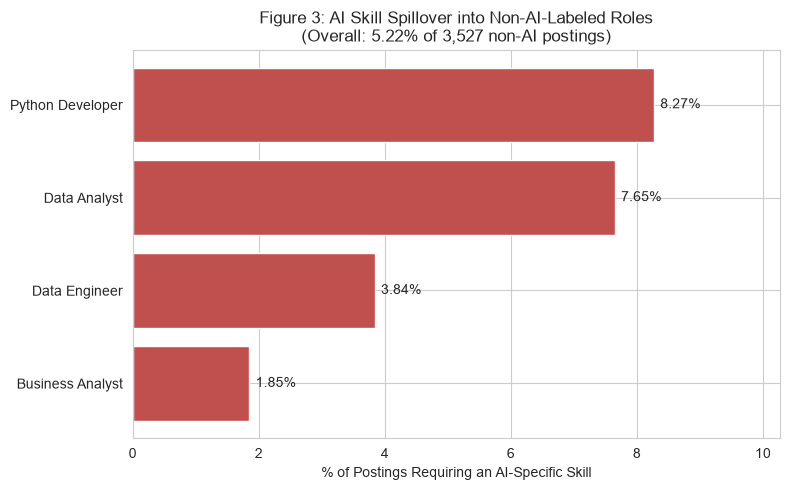

In [62]:
# Rebuild the RQ3 breakdown table with percentages (from Step 11.3)
rq3_data = non_ai_jobs.groupby('role_category')['requires_ai_skill'].agg(['sum', 'count'])
rq3_data['percentage'] = (rq3_data['sum'] / rq3_data['count'] * 100).round(2)
rq3_data = rq3_data.sort_values('percentage', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(rq3_data.index, rq3_data['percentage'], color='#C0504D')
plt.xlabel('% of Postings Requiring an AI-Specific Skill')
plt.title('Figure 3: AI Skill Spillover into Non-AI-Labeled Roles\n(Overall: 5.22% of 3,527 non-AI postings)')

# Add percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
              f'{width}%', va='center', fontsize=10)

plt.xlim(0, max(rq3_data['percentage']) + 2)
plt.tight_layout()
plt.savefig('../Output/fig3_ai_skill_spillover.png', dpi=300, bbox_inches='tight')
plt.show()

### Chart 4 (RQ4): Distribution by City, Work Mode and Experience Level

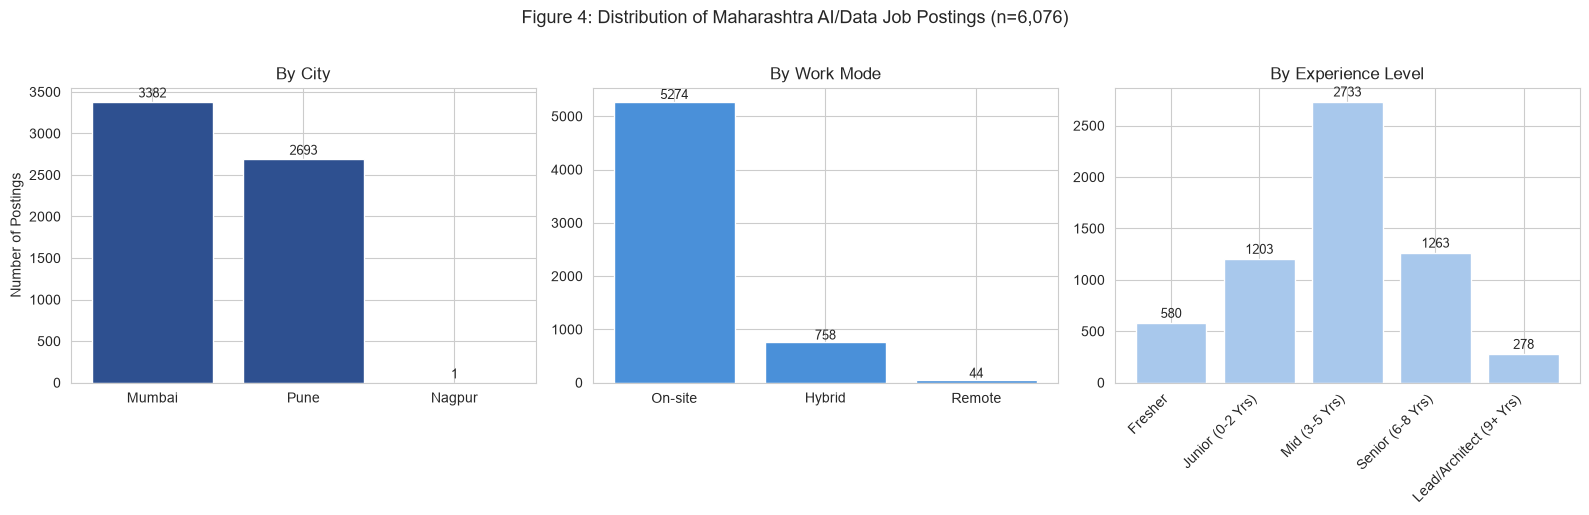

In [63]:
# Create a figure with 3 side-by-side panels (subplots)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: City distribution
city_counts = df_maharashtra['city_clean'].value_counts()
axes[0].bar(city_counts.index, city_counts.values, color='#2E5090')
axes[0].set_title('By City')
axes[0].set_ylabel('Number of Postings')
for i, v in enumerate(city_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=9)

# Panel 2: Work mode distribution
workmode_counts = df_maharashtra['work_mode'].value_counts()
axes[1].bar(workmode_counts.index, workmode_counts.values, color='#4A90D9')
axes[1].set_title('By Work Mode')
for i, v in enumerate(workmode_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=9)

# Panel 3: Experience tier distribution (reliable rows only)
exp_counts = reliable_exp['experience_tier'].value_counts()
# Order tiers logically rather than by frequency, for a more readable chart
tier_order = ['Fresher', 'Junior (0-2 Yrs)', 'Mid (3-5 Yrs)', 'Senior (6-8 Yrs)', 'Lead/Architect (9+ Yrs)']
exp_counts = exp_counts.reindex(tier_order)
axes[2].bar(range(len(exp_counts)), exp_counts.values, color='#A8C8EC')
axes[2].set_xticks(range(len(exp_counts)))
axes[2].set_xticklabels(exp_counts.index, rotation=45, ha='right')
axes[2].set_title('By Experience Level')
for i, v in enumerate(exp_counts.values):
    axes[2].text(i, v + 50, str(v), ha='center', fontsize=9)

plt.suptitle('Figure 4: Distribution of Maharashtra AI/Data Job Postings (n=6,076)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../Output/fig4_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### Chart 5 (RQ5): Relationship Between Skills, Experience and Salary

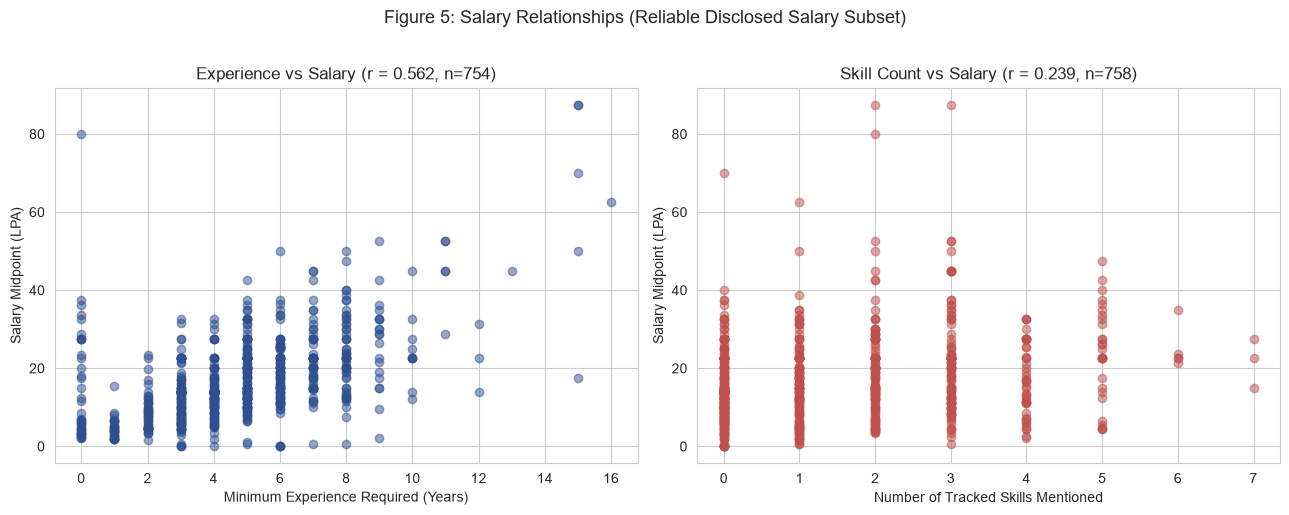

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Experience vs Salary (scatter)
axes[0].scatter(salary_exp_subset['experience_min_yrs'], salary_exp_subset['salary_midpoint_lpa'],
                 alpha=0.5, color='#2E5090')
axes[0].set_xlabel('Minimum Experience Required (Years)')
axes[0].set_ylabel('Salary Midpoint (LPA)')
axes[0].set_title(f'Experience vs Salary (r = 0.562, n={len(salary_exp_subset)})')

# Panel 2: Tracked skill count vs Salary (scatter)
axes[1].scatter(salary_subset['tracked_skill_count'], salary_subset['salary_midpoint_lpa'],
                 alpha=0.5, color='#C0504D')
axes[1].set_xlabel('Number of Tracked Skills Mentioned')
axes[1].set_ylabel('Salary Midpoint (LPA)')
axes[1].set_title(f'Skill Count vs Salary (r = 0.239, n={len(salary_subset)})')

plt.suptitle('Figure 5: Salary Relationships (Reliable Disclosed Salary Subset)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../Output/fig5_salary_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

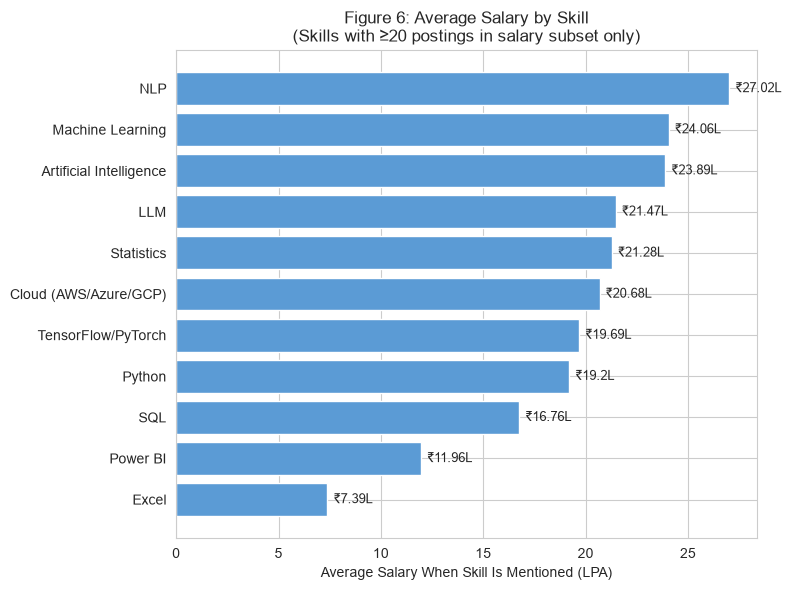

In [66]:
# Filter to skills with a reasonably reliable sample size (>=20 postings) for this specific chart,
# per the caution we flagged in Step 11.5 — avoids showing misleading averages from tiny samples
reliable_skill_salary = skill_salary_df[skill_salary_df['postings_with_skill_in_salary_subset'] >= 20].copy()
reliable_skill_salary = reliable_skill_salary.sort_values('avg_salary_with_skill', ascending=True)

plt.figure(figsize=(8, 6))
bars = plt.barh(reliable_skill_salary['skill'], reliable_skill_salary['avg_salary_with_skill'], color='#5B9BD5')
plt.xlabel('Average Salary When Skill Is Mentioned (LPA)')
plt.title('Figure 6: Average Salary by Skill\n(Skills with ≥20 postings in salary subset only)')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2, f'₹{width}L', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../Output/fig6_avg_salary_by_skill.png', dpi=300, bbox_inches='tight')
plt.show()

## Phase 13: Interpretation of Findings

### RQ1 — Which AI skills are most demanded in Maharashtra job postings?
SQL (22.96%) and Python (21.74%) are the two most frequently mentioned skills across
6,076 Maharashtra postings, followed by Cloud platforms (16.87%) and Machine Learning
(14.68%). Together, this suggests that core programming/query ability and cloud
familiarity are currently more foundational to Maharashtra's data job market than
specialized AI techniques (NLP, LLM, Computer Vision, MLOps all under 5%). This does
not mean specialized AI skills are unimportant — it means they are still a minority
requirement relative to general-purpose data skills, at least as explicitly stated in
posting text (see limitations).

### RQ2 — How frequently are Python, SQL and Power BI mentioned?
SQL and Python are mentioned at similar, high rates (~22-23%), while Power BI trails
considerably (4.94%) — a nearly 5x gap. This indicates Maharashtra's data job market
currently prioritizes programming/query skills over specific BI visualization tools,
at least in explicit posting text.

### RQ3 — How frequently do non-AI jobs require AI-related skills?
Among 3,527 postings not labeled as Data Scientist/ML Engineer roles, 5.22% (184
postings) still showed text evidence of an AI-specific skill. This "spillover" was
uneven: Python Developer (8.27%) and Data Analyst (7.65%) roles showed AI-skill
mentions roughly 4x more often than Business Analyst roles (1.85%). This is modest
but real evidence that AI skill expectations are beginning to extend beyond
dedicated AI/ML job titles into adjacent technical roles — directly supporting the
"emerging skill requirements" theme of this research.

### RQ4 — Distribution of postings by location, experience and work mode
Mumbai (55.7%) and Pune (44.3%) together account for nearly all Maharashtra postings
in this dataset, with Nagpur represented by a single posting — meaning findings
describe the Mumbai-Pune tech corridor specifically, not Maharashtra as a whole.
On-site work dominates (86.8%), with remote arrangements nearly absent (0.7%).
Mid-level experience (3-5 years) is the largest single group (45.1%), while
fresher-level postings are comparatively rare (9.6%), suggesting the market (as
captured by this dataset) favors already-experienced candidates over new graduates.

### RQ5 — Relationship between skills, experience and salary
Among 758 postings with reliable disclosed salary, experience shows a moderate-strong
positive correlation with salary (r=0.562), while tracked skill count shows only a
weak positive correlation (r=0.239). Examined skill-by-skill, AI/ML-specific skills
(Artificial Intelligence, Machine Learning) show the clearest salary premiums
(~+₹8 LPA) among well-supported samples (n>100), while foundational tools like SQL
show no premium, and Power BI/Excel show a salary discount — likely reflecting their
association with more junior/entry-level roles rather than a causal salary effect.
These are associations, not causal claims.

## Phase 14: Preparing the Final Research Dataset

In [67]:
# Before exporting, see every column currently in df_maharashtra
print("Total columns:", len(df_maharashtra.columns))
for i, col in enumerate(df_maharashtra.columns, start=1):
    print(i, "-", col)

Total columns: 54
1 - job_id
2 - job_title
3 - company_name
4 - company_rating
5 - location
6 - scraped_city
7 - role_category
8 - experience_raw
9 - experience_min_yrs
10 - experience_max_yrs
11 - salary_raw
12 - salary_min_lpa
13 - salary_max_lpa
14 - salary_disclosed
15 - skills_required
16 - skills_count
17 - job_description
18 - posted_date_raw
19 - work_mode
20 - company_size_bucket
21 - job_url
22 - data_source
23 - scraped_at
24 - salary_tier
25 - experience_tier
26 - is_senior
27 - primary_city
28 - skill_domain
29 - salary_midpoint_lpa
30 - days_since_posted
31 - is_fresher_friendly
32 - salary_negotiable
33 - city_clean
34 - job_title_clean
35 - experience_data_reliable
36 - salary_data_reliable
37 - skill_Python
38 - skill_SQL
39 - skill_Power BI
40 - skill_Machine Learning
41 - skill_Deep Learning
42 - skill_Artificial Intelligence
43 - skill_NLP
44 - skill_LLM
45 - skill_MLOps
46 - skill_TensorFlow/PyTorch
47 - skill_Computer Vision
48 - skill_Excel
49 - skill_Tableau
50 

In [69]:
# Export 1: The FULL Maharashtra working dataset, with every original and derived column.
# This is your "audit trail" file — nothing removed, everything traceable.
df_maharashtra.to_csv('../Data/Processed/maharashtra_full_dataset.csv', index=False)

print("Saved: maharashtra_full_dataset.csv")
print("Rows:", len(df_maharashtra), "| Columns:", len(df_maharashtra.columns))

Saved: maharashtra_full_dataset.csv
Rows: 6076 | Columns: 54


In [70]:
# Export 2: A curated, reader-friendly version with the most relevant columns
# in a logical order, for anyone who wants to review your analysis without
# wading through all 54 columns. This does NOT replace the full export above.

final_columns = [
    'job_id', 'job_title', 'job_title_clean', 'company_name', 'role_category',
    'city_clean', 'work_mode',
    'experience_min_yrs', 'experience_max_yrs', 'experience_tier', 'experience_data_reliable',
    'salary_min_lpa', 'salary_max_lpa', 'salary_midpoint_lpa', 'salary_disclosed', 'salary_data_reliable',
    'skills_required', 'tracked_skill_count', 'requires_ai_skill', 'is_ai_labeled_role',
] + skill_columns + [
    'job_url'
]

df_final = df_maharashtra[final_columns].copy()
df_final.to_csv('../data/processed/maharashtra_research_dataset.csv', index=False)

print("Saved: maharashtra_research_dataset.csv")
print("Rows:", len(df_final), "| Columns:", len(df_final.columns))

Saved: maharashtra_research_dataset.csv
Rows: 6076 | Columns: 36


## Phase 15: Methodology and Limitations

### Data Source
The dataset consists of 23,201 real job postings scraped from Naukri.com, covering
multiple Indian cities. This project filtered to postings located in Mumbai, Pune,
and Nagpur (6,076 postings, 26.19% of the full dataset), identified via keyword
matching on the `primary_city` field since no explicit state column existed in the
source data. Postings marked "Remote" or "Pan India" were excluded from this
Maharashtra subset, as their actual location could not be verified.

### Cleaning Summary
- **Location**: 72 raw city-area variants consolidated into 3 clean city categories
  (Mumbai, Pune, Nagpur) via substring matching; original values preserved.
- **Job titles**: Case-standardized (3,679 → 3,617 unique titles); no title was
  altered in wording or bucketed into categories.
- **Experience**: 19 postings (0.31%) showed logically inconsistent values (minimum
  exceeding maximum), traced to interview dates being misparsed as experience
  figures in "Walk-in" postings. These were flagged, not deleted or corrected, and
  excluded specifically from experience-based analysis.
- **Salary**: Only 12.62% of Maharashtra postings disclosed salary (767 of 6,076).
  Of these, 9 rows showed a unit-parsing error (mixed rupee/Lacs values producing
  an implausible maximum salary) and were flagged and excluded from salary analysis,
  leaving 758 reliable rows.
- **Skills**: Extracted via a manually defined, transparent keyword dictionary (15
  skills) applied to `skills_required` and `job_description` text combined,
  deliberately excluding `job_title` to avoid assuming skills from role names alone.

### Key Limitations
1. **Geographic scope**: Findings represent the Mumbai-Pune(-Nagpur) tech corridor,
   not Maharashtra state as a whole, since no other Maharashtra cities appeared as
   distinct values in the source data.
2. **Skill list scope**: Only 15 predefined skills were tracked; other legitimate
   data/AI tools (e.g. Airflow, Kafka, Spark, R) were not tracked and would not
   register even if present in a posting's text.
3. **Skills text truncation**: The source data appears to cap listed skills at
   around 8 items per posting, meaning some postings may require more skills than
   captured.
4. **Salary sample size**: Only 758 postings (12.5% of the Maharashtra subset) had
   reliable disclosed salary, limiting the statistical strength of RQ5's findings.
5. **Single time-point snapshot**: All postings were scraped on a single date
   (2025-06-10) with relative posted-dates (e.g. "2 weeks ago"), so this analysis
   reflects a snapshot in time, not a multi-period trend.
6. **Association, not causation**: All relationships reported (e.g. skill-salary,
   experience-salary) are statistical associations only; no causal claims are made
   or supported by this analysis.
7. **Text-based detection limitation**: A skill marked "False" means no evidence of
   that skill was found in the available text — it does not confirm the skill is
   genuinely absent from the role's actual requirements.

### Reproducibility
All cleaning and analysis steps were performed in this Jupyter notebook using pandas,
with every transformation applied to a working copy (`df` / `df_maharashtra`),
never the original raw file. Two final datasets were exported: a full version
retaining every derived column, and a curated version for direct reference in
this report.